# Slingshot

In [ ]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("slingshot")
# BiocManager::install("S4Vectors")
# BiocManager::install("SingleCellExperiment")
# BiocManager::install("tradeSeq")

https://nbisweden.github.io/workshop-archive/workshop-scRNAseq/2020-01-27/labs/compiled/slingshot/slingshot.html#basic_processing_with_seurat_pipeline

In [9]:
# Library import
library(Seurat)
library(ggplot2)
library(patchwork)
library(dplyr)
library(magrittr)
library(S4Vectors)
library(SingleCellExperiment)
library(slingshot)
library(tradeSeq)

In [10]:
# Multicore CPU usage activation - Future

library(future)

plan("multicore", workers = 24)

options(future.globals.maxSize = 64000 * 1024^2)

future.seed = TRUE # Removes future-generated statistical errors

In [28]:
Seurat <- readRDS('seurat_codeconv.rds')

In [29]:
Seurat <- subset(Seurat, idents = c("Tumor Core", "Tumor Front", "Tumor Edge"))

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


In [30]:
Seurat <- subset(Seurat, subset = UMAP_1 > 0 & UMAP_2 < 0)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


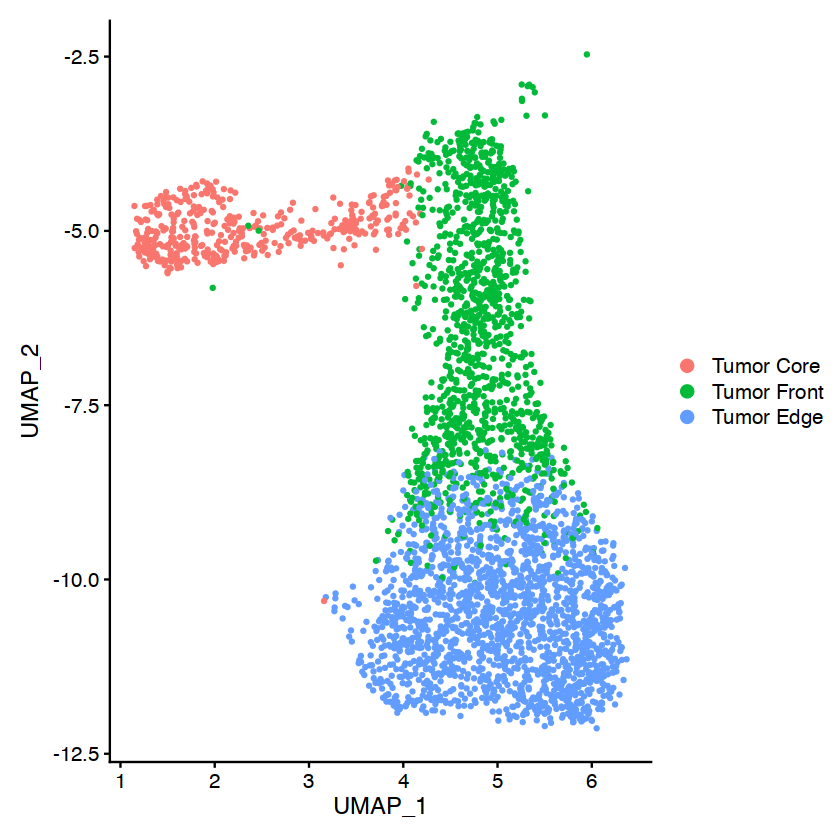

In [16]:
# Seurat Clusters
p <- DimPlot(Seurat, 
              reduction = "umap",
              label = FALSE, pt.size = 0.75, 
              label.size = 3, repel = TRUE)

p

In [5]:
Seurat

An object of class Seurat 
17896 features across 11264 samples within 1 assay 
Active assay: Spatial (17896 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [13]:
Seurat@reductions

$pca
A dimensional reduction object with key PC_ 
 Number of dimensions: 50 
 Number of cells: 3530 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: Spatial 

$umap
A dimensional reduction object with key UMAP_ 
 Number of dimensions: 2 
 Number of cells: 3530 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: Spatial 


In [14]:
Seurat@assays

$Spatial
Assay (v5) data with 17896 features for 3530 cells
Top 10 variable features:
 IGLC1, IGKC, IGHG2, IGHG1, IGKV4-1, LCN2, SPRR2D, SPRR2A, PI3, LCE3D 
Layers:
 counts, data, scale.data 


In [15]:
head(Seurat@meta.data)

,orig.ident,nCount_Spatial,nFeature_Spatial,Spatial_snn_res.0.5,seurat_clusters,CellType
,<chr>,<dbl>,<int>,<fct>,<fct>,<fct>
AAACACCAATAACTGC-1-Topic-6-Cell-4,SeuratProject,68,65,4,4,Tumor Front
AAACATTTCCCGGATT-1-Topic-6-Cell-2,SeuratProject,463,419,4,4,Tumor Front
AAACCTAAGCAGCCGG-1-Topic-2-Cell-1,SeuratProject,183,167,9,9,Tumor Core
AAACCTAAGCAGCCGG-1-Topic-2-Cell-2,SeuratProject,577,447,9,9,Tumor Core
AAACCTAAGCAGCCGG-1-Topic-6-Cell-4,SeuratProject,4192,2431,0,0,Tumor Edge
AAACGGGCGTACGGGT-1-Topic-6-Cell-2,SeuratProject,144,138,4,4,Tumor Front


In [34]:
Zpal <- c(RColorBrewer::brewer.pal(9, "Set1"), RColorBrewer::brewer.pal(8, "Set2"))

BiocParallel::register(BiocParallel::SerialParam())

dimred <- Seurat@reductions$umap@cell.embeddings
clustering <- Seurat@meta.data$CellType
counts <- as.matrix(Seurat[["Spatial"]]$counts)

set.seed(1)

lineages <- getLineages(dimred, 
                        clustering, 
                        start.clus = 'Tumor Core',
                        end.clus = 'Tumor Edge'
                       )

curves <- getCurves(lineages, approx_points = 30, thresh = 0.01, stretch = 0.8, allow.breaks = FALSE, shrink = 0.99)

sce <- fitGAM(counts = counts, sds = curves)

startRes <- startVsEndTest(sce)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the tradeSeq package.
  Please report the issue at <https://github.com/statOmics/tradeSeq/issues>.”


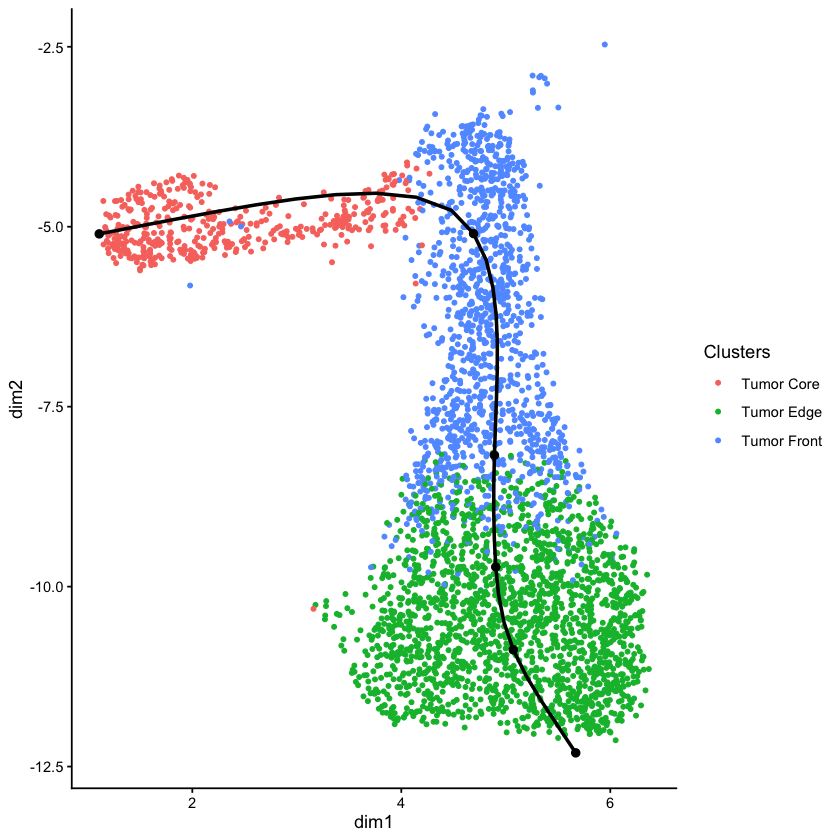

In [35]:
plotGeneCount(curves, counts, clusters = clustering, models = sce)

In [46]:
# Save the last plot

ggsave(
  "Trajectories.jpeg", plot = last_plot(),
       width = 7.6, height = 6,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


In [47]:
library(dplyr)
plot_differential_expression <- function(feature_id) {
    feature_id <- pseudotime_association %>% filter(pvalue < 0.05) %>% top_n(1, -waldStat) %>% pull(feature_id)
    cowplot::plot_grid(plotGeneCount(curves, counts, gene = feature_id[1], clusters = clustering, models = sce) + ggplot2::theme(legend.position = "none"), 
        plotSmoothers(sce, as.matrix(counts), gene = feature_id[1]))
    }

In [48]:
pseudotime_association <- associationTest(sce)
pseudotime_association$fdr <- p.adjust(pseudotime_association$pvalue, method = "fdr")
pseudotime_association <- pseudotime_association[order(pseudotime_association$pvalue), ]
pseudotime_association$feature_id <- rownames(pseudotime_association)

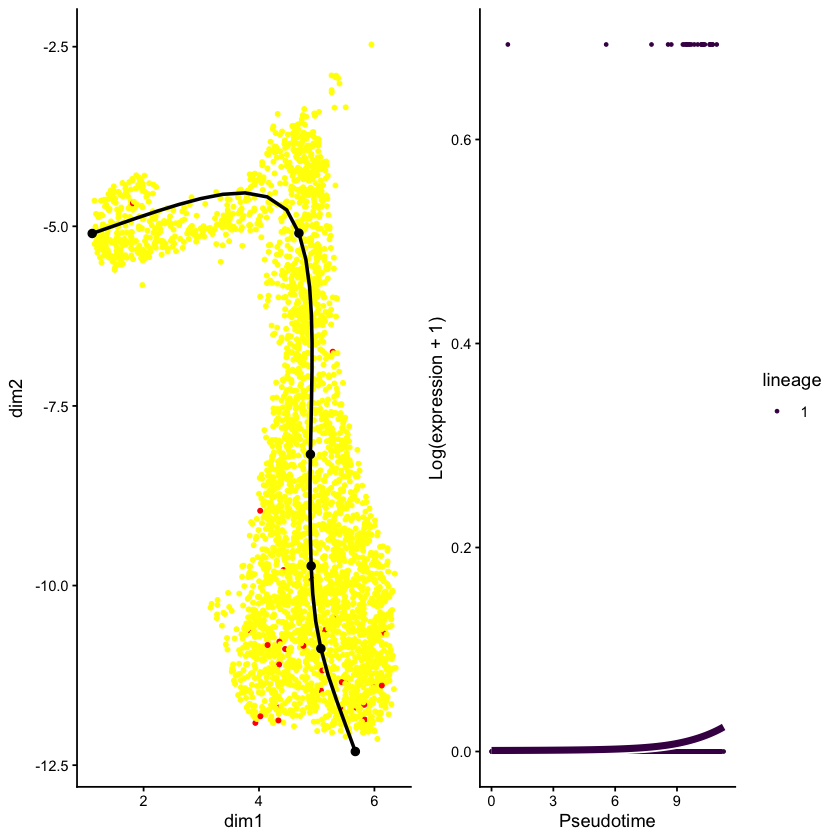

In [49]:
feature_id <- pseudotime_association %>% filter(pvalue < 0.05) %>% top_n(1, -waldStat) %>% pull(feature_id)
plot_differential_expression(feature_id)

In [94]:
library(dplyr)
library(tidyr)

yhat_summary <- yhat %>%
  arrange(gene, time) %>%
  group_by(gene) %>%
  summarize(
    start_val = dplyr::first(yhat),
    end_val = dplyr::last(yhat),
    .groups = "drop"
  ) %>%
  mutate(logFC = log2(end_val + 1) - log2(start_val + 1))

startRes$logFC <- yhat_summary$logFC[match(rownames(startRes), yhat_summary$gene)]

edge_genes_list <- rownames(startRes[which(startRes$pvalue < 0.05 & startRes$logFC > 0.5), ])
core_genes_list <- rownames(startRes[which(startRes$pvalue < 0.05 & startRes$logFC < -0.5), ])

edge_genes <- edge_genes_list[order(startRes[edge_genes_list, "logFC"], decreasing = TRUE)]
core_genes <- core_genes_list[order(startRes[core_genes_list, "logFC"], decreasing = FALSE)]

head(edge_genes, 40)
head(core_genes, 40)

[1] "TMSB4X"  "B2M"     "MMP14"   "PABPC1"  "ACTB"    "IGFBP7"  "TNC"    
 [8] "MMP1"    "FTL"     "FTH1"    "KRT14"   "PFN1"    "KRT5"    "COL6A1" 
[15] "ATP5F1B" "COL17A1" "MMP13"   "LMNA"    "CTSD"    "UBA52"   "AEBP1"  
[22] "RBM3"    "CD99"    "SPON2"   "ARPC2"   "BRI3"    "PTK7"    "PPDPF"  
[29] "TP63"    "GABARAP" "SERBP1"  "BGN"     "TIMP3"   "DDR1"    "POLR2L" 
[36] "GNB1"    "GJA1"    "MYH9"    "CD81"    "APP"

[1] "UBC"       "COL3A1"    "COL1A1"    "COL1A2"    "SPARC"     "FN1"      
 [7] "CXCL9"     "WARS"      "CST1"      "HLA-DRA"   "TPM2"      "COL6A3"   
[13] "GBP1"      "CXCL11"    "ISG15"     "PLAUR"     "LYZ"       "KLK10"    
[19] "HLA-DPA1"  "IFITM1"    "UBE2C"     "DES"       "HIST1H2AG" "CCN2"     
[25] "CXCL10"    "TPX2"      "HIST1H3H"  "S100A8"    "HLA-DRB1"  "HIST1H1E" 
[31] "IFIT3"     "KRT6B"     "CTSC"      "TIMP1"     "HIST1H1B"

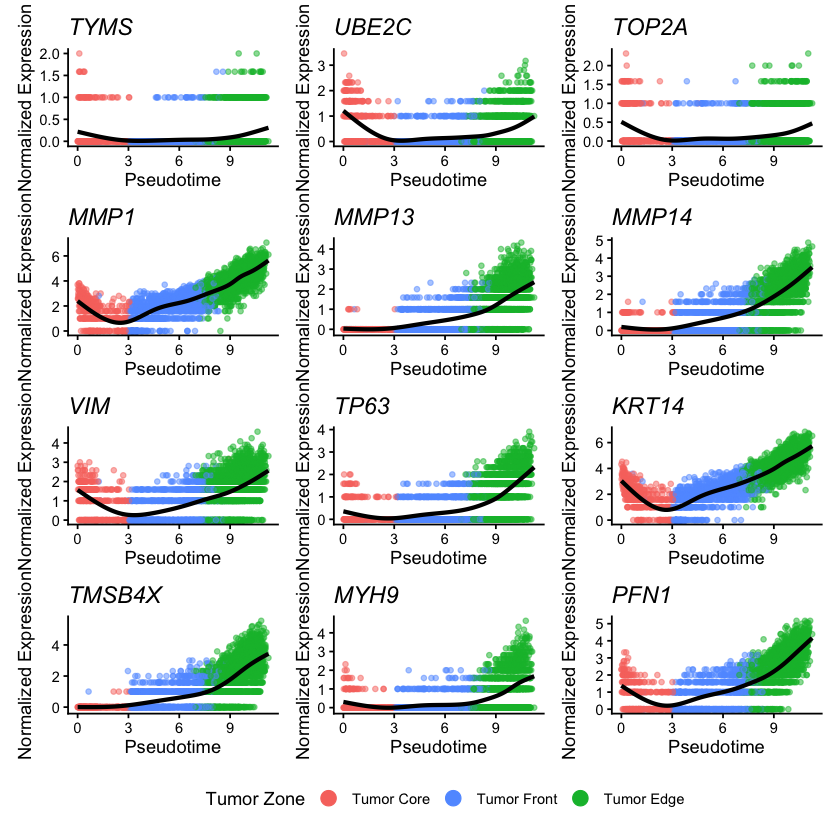

In [103]:
genes_to_plot <- c("TYMS", "UBE2C", "TOP2A",
                   "MMP1", "MMP13", "MMP14", 
                   "VIM", "TP63", "KRT14",
                   "TMSB4X", "MYH9", "PFN1")

pst_data <- slingPseudotime(curves)[, 1]
# # Normed counts
# exp_matrix <- as.matrix(Seurat[["Spatial"]]$data[genes_to_plot, colnames(Seurat)])
# Log(Raw COunts)
exp_matrix <- as.matrix(Seurat[["Spatial"]]$data[genes_to_plot, colnames(Seurat)])
exp_matrix <- log2(as.matrix(Seurat[["Spatial"]]$counts[genes_to_plot, colnames(Seurat)]) + 1)

df_base <- data.frame(
  Cell = colnames(Seurat),
  Pseudotime = pst_data,
  Zone = Seurat@meta.data[colnames(Seurat), "CellType"]
)

df_master <- cbind(df_base, t(exp_matrix)) %>% 
  filter(!is.na(Pseudotime))

seu_cols <- scales::hue_pal()(3)[c(1, 3, 2)]
names(seu_cols) <- c("Tumor Core", "Tumor Front", "Tumor Edge")

plot_list <- lapply(genes_to_plot, function(gene_name) {
  ggplot(df_master, aes(x = Pseudotime, y = .data[[gene_name]])) +
    geom_point(aes(color = Zone), alpha = 0.5, size = 1.2) +
    geom_smooth(method = "gam", formula = y ~ s(x, bs = "cs"), 
                color = "black", linewidth = 1.2, se = TRUE, fill = "gray80") +
    scale_color_manual(values = seu_cols) +
    labs(title = gene_name, x = "Pseudotime", y = "Normalized Expression") +
    theme_classic() +
    theme(
      plot.title = element_text(face = "italic", size = 14),
      legend.position = "none"
    )
})

wrap_plots(plot_list) + 
  plot_layout(guides = "collect", ncol = 3) & 
  theme(legend.position = "bottom") &
  guides(color = guide_legend(title = "Tumor Zone", override.aes = list(alpha = 1, size = 4)))

In [104]:
# Save the last plot

ggsave(
  "Trajectories MMPs & Cycle Genes.jpeg", plot = last_plot(),
       width = 10.5, height = 15,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”
